jaxlib._jax.ArrayImpl

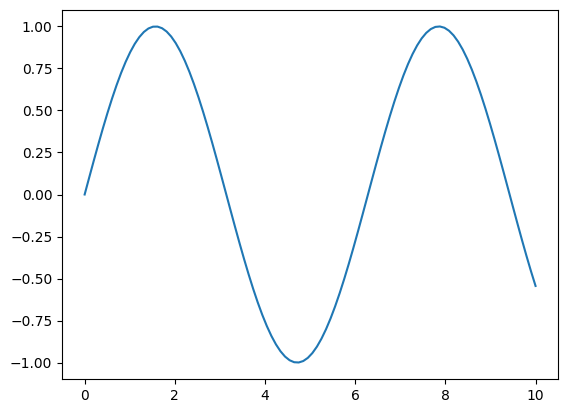

In [15]:
## jax ? 

import jax.numpy as jnp
import jax 
import matplotlib.pyplot as plt 
x_jnp = jnp.linspace(0,10,100 )
y_jnp = jnp.sin(x_jnp)
plt.plot(x_jnp, y_jnp)

type(x_jnp)

In [16]:
x_jnp.devices()

{CpuDevice(id=0)}

In [17]:
x_small = jnp.arange(3.)
x_small

Array([0., 1., 2.], dtype=float32)

In [18]:
from jax import jacobian
print(jacobian(jnp.exp)(x_small))

[[1.        0.        0.       ]
 [0.        2.7182817 0.       ]
 [0.        0.        7.389056 ]]


In [19]:
#from jax import random 
key = jax.random.key(1701)
key1, key2 = jax.random.split(key)
mat = jax.random.normal(key2, (10,100))
batched_x = jax.random.normal(key2, (10, 100))

def apply_matrix(x):
  return jnp.dot(mat, x)


In [20]:
def naively_batched_apply_matrix(v_batched):
  return jnp.stack([apply_matrix(v) for v in v_batched])

print('Naively batched')
%timeit naively_batched_apply_matrix(batched_x).block_until_ready()
naively_batched_apply_matrix(batched_x).shape

Naively batched
352 μs ± 18.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


(10, 10)

In [27]:
import jax
import jax.numpy as jnp
import numpy as np

@jit 
def batched_apply_matrix(batched_x): 
    return jnp.dot(batched_x,mat.T)

np.testing.assert_allclose(naively_batched_apply_matrix(batched_x),
                           batched_apply_matrix(batched_x), atol=1E-4, rtol=1E-4)
print('Manually batched')
%timeit batched_apply_matrix(batched_x).block_until_ready()

Manually batched
8.9 μs ± 717 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [28]:
##VMAP - automatical batching 
from jax import vmap 

@jit 
def vmap_batched_apply_matrix(batched_x): 
    return vmap(apply_matrix)(batched_x)

np.testing.assert_allclose(naively_batched_apply_matrix(batched_x),
                           vmap_batched_apply_matrix(batched_x), atol=1E-4, rtol=1E-4)
print('Auto-vectorized with vmap')
%timeit vmap_batched_apply_matrix(batched_x).block_until_ready()

Auto-vectorized with vmap
6.65 μs ± 1.31 μs per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [29]:
## tensors 
a = jnp.array([[[[1,2,3],[0,1,2]]]])
a.shape

(1, 1, 2, 3)

In [30]:
@jax.jit
def f(x):
  jax.debug.print("jax.debug.print(x) -> {x}", x=x)
  print(x) ##doesn't work lol 
  y = jnp.sin(x)
  jax.debug.print("jax.debug.print(y) -> {y}", y=y)
  return y

result = f(2.)

JitTracer(~float32[])
jax.debug.print(x) -> 2.0
jax.debug.print(y) -> 0.9092974066734314


## NetKet

In [31]:
import os 
import jax
os.environ["JAX_PLATFORM_NAME"] = "cpu"
import netket as nk 

N = 20 
hi = nk.hilbert.Spin(s=1/2 ,N = N ) ## size is 2^20 ~ 10^6
hi.random_state(jax.random.key(0),3 )


/Users/ilyayakushevskiy/Desktop/FermiNQS/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: You can plot data with JsonLog.data['Energy'][:-30].plot().

Array([[-1, -1, -1, -1, -1, -1,  1,  1,  1,  1,  1, -1,  1,  1, -1,  1,
         1, -1, -1,  1],
       [ 1,  1,  1, -1, -1,  1,  1,  1, -1, -1,  1,  1,  1, -1, -1,  1,
        -1,  1,  1,  1],
       [ 1, -1,  1, -1, -1,  1,  1,  1,  1, -1,  1,  1, -1,  1, -1, -1,
         1,  1, -1, -1]], dtype=int8)

In [32]:
from netket.operator.spin import sigmax, sigmaz

Gamma = -1 
H = sum( [Gamma * sigmax(hi, i) for i in range(N) ])

V = -1 
# @ is kroneker product 
#act with H on state 
H += sum( [  V * sigmaz(hi,i) @ sigmaz(hi, (i+1) % N )  for i in range(N)])

sp_h = H.to_sparse()
sp_h.shape

from scipy.sparse.linalg import eigsh
# EV of H are eigenenergies 
eig_vals, eig_vecs = eigsh(sp_h, k=22, which="SA")

print("eigenvalues with scipy sparse:", eig_vals)

E_gs = eig_vals[0]
eig_vecs.shape
# cool , there are ~10^6 eigen energies but we have to find GS energy 

 

eigenvalues with scipy sparse: [-25.49098969 -25.41240947 -24.86331692 -24.78667161 -24.78667161
 -24.24337185 -24.24337185 -24.24337185 -24.24337185 -24.17634149
 -24.17634149 -24.16093375 -23.64641957 -23.64641957 -23.64641957
 -23.62342678 -23.59644747 -23.59644747 -23.55060363 -23.55060363
 -23.55060363 -23.08715904]


(1048576, 22)

In [33]:
from flax import nnx 


class MF(nnx.Module): 

    # heres a joke: "self" is actually just a convention (german python can't hurt you)
    def __init__(selbst , * , rngs: nnx.Rngs): 
        key = rngs.params() # generates the key and splits the key for each parameter 

        #log WF 
        selbst.log_phi_local = nnx.Param(jax.random.normal(key, (1,))) #single weight 

    def __call__(selbst, x : jax.Array):
        #proba  
        p = nnx.log_sigmoid(selbst.log_phi_local * x )
        return 0.5 * jnp.sum(p, -1 ) #sum of logs is product of exp states 
    




In [34]:
mf_model = MF(rngs = nnx.Rngs(0))
sampler = nk.sampler.MetropolisLocal(hilbert= hi)

#variational state 
vstate = nk.vqs.MCState(sampler, mf_model, n_samples= 15012)


/Users/ilyayakushevskiy/Desktop/FermiNQS/.venv/lib/python3.12/site-packages/netket/vqs/mc/mc_state/state.py:314: UserWarning: n_samples=15012 (15012 per JAX device) does not divide n_chains=16, increased to 15024 (15024 per JAX device)
  self.n_samples = n_samples


In [35]:
print(vstate.parameters)
E = vstate.expect(H)
print(E)
print("Mean                  :", E.mean)
print("Error                 :", E.error_of_mean)
print("Variance              :", E.variance)
print("Convergence indicator :", E.R_hat)
print("Correlation time      :", E.tau_corr)

{'log_phi_local': Array([1.88002989], dtype=float64)}
-24.364 ± 0.022 [σ²=5.6e+00, R̂=1.001]
Mean                  : -24.363788054370186
Error                 : 0.021903910938657484
Variance              : 5.647166369921507
Convergence indicator : 1.0005910323660578
Correlation time      : 0.13821693885880526


In [36]:

from tqdm import tqdm 

energy_history = [] 

n_steps = 100

for i in tqdm(range(n_steps) ):
    E, E_grad = vstate.expect_and_grad(H)
    energy_history.append(E.mean.real)

    new_pars = jax.tree_util.tree_map(lambda x,y : x - 0.05 * y, vstate.parameters, E_grad)

    vstate.parameters = new_pars
     


100%|██████████| 100/100 [00:10<00:00,  9.40it/s]


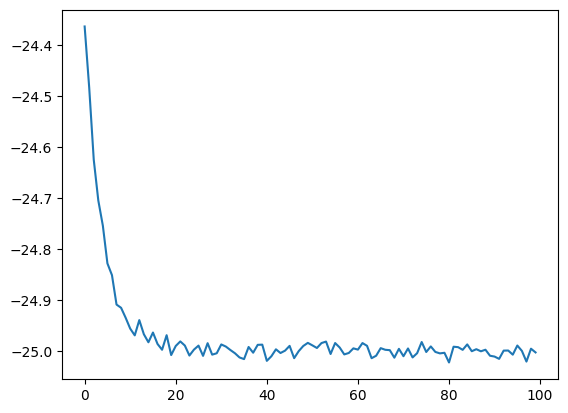

In [37]:
import matplotlib.pyplot as plt 

plt.plot(energy_history)



In [38]:
E_gs

np.float64(-25.49098968636478)

## NQS

In [58]:
class FFN(nnx.Module): 
    def __init__(self, N : int , alpha: int = 1 , * , rngs: nnx.Rngs): 
        self.alpha = alpha 
        self.linear = nnx.Linear(in_features=N, out_features= alpha* N, rngs=rngs)

    def __call__(self, x : jax.Array):
        y = self.linear(x)
        y = nnx.relu(y)
        return jnp.sum(y, axis=-1)
    
model = FFN(N =N , alpha= 1 , rngs= nnx.Rngs(2))
vstate = nk.vqs.MCState(sampler, model , n_samples= 10080) 




optimizer = nk.optimizer.Sgd(learning_rate=0.009)

# Notice the use, again of Stochastic Reconfiguration, which considerably improves the optimisation
gs = nk.driver.VMC_SR(
    H, #what exactly is this H?? We initialised it from random hi a while ago, shouln't it be reinitialised? 
    optimizer,
    variational_state=vstate,
    diag_shift = 0.1 #Only for VMC_SR
)

log = nk.logging.RuntimeLog()
gs.run(n_iter=300, out=log)

ffn_energy = vstate.expect(H)
error = abs((ffn_energy.mean - eig_vals[0]) / eig_vals[0])
print("Optimized energy and relative error: ", ffn_energy, error)




Automatic SR implementation choice:  QGT


100%|██████████| 300/300 [00:37<00:00,  8.06it/s, Energy=-25.4172 ± 0.0069 [σ²=4.8e-01, R̂=1.001]]


Optimized energy and relative error:  -25.4186 ± 0.0069 [σ²=4.6e-01, R̂=1.001] 0.00284117558992954


In [60]:
E_gs
vstate #the vstate vector is never build explicitly , that would be 2^N * bytes per entry memory :))

MCState(
  hilbert = Spin(s=1/2, N=20, ordering=new),
  sampler = MetropolisSampler(rule = LocalRule(), n_chains = 16, sweep_size = 20, reset_chains = False, machine_power = 2, dtype = int8),
  n_samples = 10080,
  n_discard_per_chain = 5,
  sampler_state = MetropolisSamplerState(# accepted = 52453/203200 (25.813484251968504%), rng state=Array((), dtype=key<fry>) overlaying:
[ 158399894 1695440244]),
  n_parameters = 420)

In [62]:
##what are actual spins ? 

local_spins = np.zeros(N)

for i in range(N): 

    obs_i = sigmaz(hi, i)

    exp_value = vstate.expect(obs_i)

    local_spins[i] = exp_value.mean.real

local_spins


array([0.6422619 , 0.64285714, 0.64365079, 0.6484127 , 0.65714286,
       0.66825397, 0.67162698, 0.67619048, 0.6468254 , 0.64365079,
       0.6343254 , 0.62063492, 0.61289683, 0.61269841, 0.59246032,
       0.60694444, 0.61706349, 0.58531746, 0.59940476, 0.62480159])

## Some examples with my code 
 

In [8]:
import hydra
from omegaconf import DictConfig


import jax
import netket as nk
from flax import nnx 
import logging

from src.system import System
from src.ansatz import Gaussian, DeepSetsNN
from src.train import Trainer

from hydra import initialize, compose
from omegaconf import DictConfig

def run(cfg: DictConfig):
    log.info(f"starting experiment with config: {cfg}")

    system = System(
        N=cfg.system.N,
        dim=cfg.system.dim,
        mass=cfg.system.mass,
        potential=cfg.system.potential,
    )

    if cfg.ansatz.model == "gaussian":
        ansatz = Gaussian(
            dim=cfg.system.dim,
            rngs=nnx.Rngs(42),
            N=cfg.system.N,
        )

    elif cfg.ansatz.model == "deep_sets":
        ansatz = DeepSetsNN(
            dim=cfg.system.dim,
            rngs=nnx.Rngs(42),
            N=cfg.system.N,
        )

    

    sampler = nk.sampler.MetropolisGaussian(
        system.hi,
        sigma=0.1,
        n_chains=16,
        sweep_size=32,
    )

    trainer = Trainer(
        sampler=sampler,
        hamiltonian=system.H,
        model=ansatz,
        lr=cfg.trainer.lr,
        vmc_iters=cfg.trainer.vmc_iters,
        log=log,
    )
    nnx.display(ansatz)
    #trainer()

from hydra import initialize, compose

with initialize(config_path="configs", version_base=None):
    cfg = compose(
        config_name="train",
        overrides=[
            "+experiment=qho_bosons_deepsets",
            "ansatz.model=deep_sets",
            "trainer.lr=1e-3",
        ],
    )

run(cfg)

NameError: name 'ansatz' is not defined